<a href="https://colab.research.google.com/github/Charyoe/ML-with-Python-Bootcamp/blob/main/Capstone_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project Part 1: Use Saved Logistic Regression Model on New Customers

**Goal:** Use a logistic regression model to predict whether new customers will buy a product using **Age** and **Salary**.

## Dataset

- Training dataset: `DigitalAd_dataset.csv`
- New customer dataset: `new_customers_200.csv`
- Target column in the training dataset: `Status`

**Note:** The assignment says 200 new customers, but the uploaded `new_customers_200.csv` contains **191 rows**.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


## Step 1: Train and Save the Logistic Regression Model

This step trains the model and saves `model.pkl` and `scaler.pkl`.

## Step 2: Load the Saved Model and Predict New Customers

In [2]:
# Load data, train model, and predict new customers

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# GitHub raw URLs
train_url = "https://raw.githubusercontent.com/Charyoe/ML-with-Python-Bootcamp/main/DigitalAd_dataset.csv"
new_url = "https://raw.githubusercontent.com/Charyoe/ML-with-Python-Bootcamp/main/new_customers_200.csv"

# Load training data
df = pd.read_csv(train_url)

# Prepare features and target
X = df[['Age', 'Salary']]
y = df['Status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(random_state=0)
model.fit(X_train_scaled, y_train)

# Save model and scaler
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Load new customer data
new_df = pd.read_csv(new_url)

# Predict new customers
X_new = new_df[['Age', 'Salary']]
X_new_scaled = scaler.transform(X_new)

new_df['Prediction'] = model.predict(X_new_scaled)
new_df['Buy_Probability'] = model.predict_proba(X_new_scaled)[:, 1]

# Print required output
print("First 10 rows with predictions:")
print(new_df.head(10))

print("\nNumber of customers predicted to buy:")
print(new_df['Prediction'].sum())

print("\nAverage probability of buying:")
print(new_df['Buy_Probability'].mean())

First 10 rows with predictions:
   Age  Salary  Prediction  Buy_Probability
0   25   52000           0         0.013500
1   42   89000           1         0.574372
2   33   62000           0         0.084434
3   55  105000           1         0.967437
4   29   48000           0         0.025473
5   38   75000           0         0.276670
6   45   92000           1         0.729008
7   31   58000           0         0.051579
8   50   98000           1         0.897844
9   27   51000           0         0.019194

Number of customers predicted to buy:
159

Average probability of buying:
0.8320917608427374


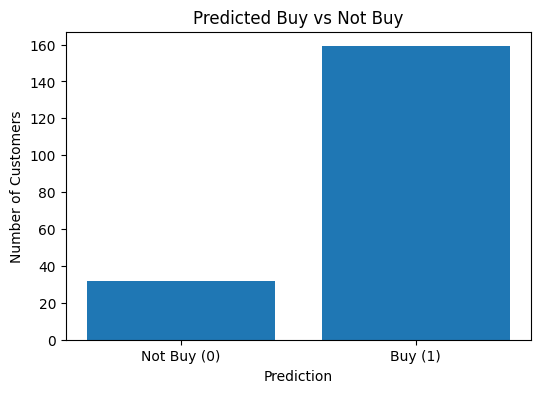

In [3]:
# Bar chart of predicted buy vs not buy
counts = new_df['Prediction'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Not Buy (0)', 'Buy (1)'], [counts.get(0, 0), counts.get(1, 0)])
plt.title('Predicted Buy vs Not Buy')
plt.xlabel('Prediction')
plt.ylabel('Number of Customers')
plt.show()


In [4]:
# Save predictions to CSV
new_df.to_csv("part1_predictions.csv", index=False)
print("Saved: part1_predictions.csv")


Saved: part1_predictions.csv


## Questions for Part 1

### Q1. How many of the 200 new customers are predicted to buy?

**Answer:** The uploaded file contains **191 customers**, not 200. The model predicts **159 customers** to buy.

### Q2. What is the average probability of buying among all 200?

**Answer:** The average probability of buying among the uploaded **191 customers** is approximately **0.8321**, or **83.21%**.

### Q3. Look at the bar chart. Does the model predict more buyers or non-buyers? What could that mean for the business?

**Answer:** The model predicts more **buyers** than **non-buyers**. This could mean that many of the new customers have Age and Salary patterns similar to customers who bought the product in the training data. For the business, these customers may be good targets for marketing and sales campaigns.

### Q4. If a new customer has Age = 30 and Salary = 65000, would the model predict buy or not buy? Explain how you would find out.

**Answer:** To find out, create a one-row DataFrame with Age = 30 and Salary = 65000, scale it using the saved scaler with `.transform()`, and then use `model.predict()`. Using this trained model, the prediction is **Not Buy (0)**, with a buying probability of about **5.37%**.

In [5]:
# Test customer: Age = 30, Salary = 65000
single_customer = pd.DataFrame([[30, 65000]], columns=['Age', 'Salary'])

single_scaled = scaler.transform(single_customer)
single_prediction = model.predict(single_scaled)[0]
single_probability = model.predict_proba(single_scaled)[0, 1]

print("Prediction:", single_prediction)
print("Buying Probability:", single_probability)


Prediction: 0
Buying Probability: 0.053711779481877324
